In [1]:
import pandas as pd
import numpy as np
movies=pd.read_csv("imdb_movies.csv",index_col=0)
movies.head()

,movies_name,budget,profit,directors_id,release_date
movies_id,,,,,
M001,Movie 001,14000000,27078718,D008,2014-07-01
M002,Movie 002,65000000,-5365617,D015,2017-06-29
M003,Movie 003,181000000,349553886,D022,2014-04-19
M004,Movie 004,30000000,42844497,D029,2024-03-25
M005,Movie 005,15000000,-3541815,D036,2012-09-17


In [3]:
movies.columns

Index(['movies_name', 'budget', 'profit', 'directors_id', 'release_date'], dtype='str')

In [22]:
directors=pd.read_csv("directors.csv")

In [25]:
type(directors)

pandas.DataFrame

In [26]:
directors.columns

Index(['directors_id', 'directors_name'], dtype='str')

In [27]:
directors.rename(columns={"directors_id":"id"},inplace=True)

In [30]:
type(directors)

pandas.DataFrame

In [35]:
movies["budget"].dtype

dtype('int64')

In [39]:
movies["directors_id"].nunique()

40

In [40]:
directors["id"].nunique()

40

In [4]:
data=movies.merge(directors,left_on="directors_id",right_on="id",how="left")

NameError: name 'movies' is not defined

In [44]:
data

,movies_name,budget,profit,directors_id,release_date,id,directors_name
0,Movie 001,14000000,27078718,D008,2014-07-01,D008,Director 008
1,Movie 002,65000000,-5365617,D015,2017-06-29,D015,Director 015
2,Movie 003,181000000,349553886,D022,2014-04-19,D022,Director 022
3,Movie 004,30000000,42844497,D029,2024-03-25,D029,Director 029
4,Movie 005,15000000,-3541815,D036,2012-09-17,D036,Director 036
...,...,...,...,...,...,...,...
115,Movie 116,80000000,118094393,D013,2018-02-09,D013,Director 013
116,Movie 117,60000000,105186922,D020,2019-09-09,D020,Director 020
117,Movie 118,137000000,148861693,D027,2017-12-02,D027,Director 027
118,Movie 119,31000000,48820439,D034,2013-02-20,D034,Director 034


In [45]:
data.drop(['id'],axis=1,inplace=True)

In [3]:
data

NameError: name 'data' is not defined

USER DEFINED FUNCTIONS IN PANDAS

In [ ]:
def square(data):
    return data**2

data["budget"].apply(square)

0        196000000000000
1       4225000000000000
2      32761000000000000
3        900000000000000
4        225000000000000
             ...        
115     6400000000000000
116     3600000000000000
117    18769000000000000
118      961000000000000
119      361000000000000
Name: budget, Length: 120, dtype: int64

In [5]:
import pandas as pd
import numpy as np
movies=pd.read_csv("imdb_movies.csv")


In [6]:
directors=pd.read_csv("directors.csv")

In [7]:
directors.rename(columns={"directors_id":"id"},inplace=True)

In [8]:
data=movies.merge(directors,left_on="directors_id",right_on="id",how="left")

In [12]:
def prof(x):
    return x["profit"]-x["budget"]

data[["profit","budget"]].apply(prof,axis=1)

0       13078718
1      -70365617
2      168553886
3       12844497
4      -18541815
         ...    
115     38094393
116     45186922
117     11861693
118     17820439
119    -29224317
Length: 120, dtype: int64

In [35]:
data.groupby("directors_name").groups

{'Director 001': [39, 79, 119], 'Director 002': [22, 62, 102], 'Director 003': [5, 45, 85], 'Director 004': [28, 68, 108], 'Director 005': [11, 51, 91], 'Director 006': [34, 74, 114], 'Director 007': [17, 57, 97], 'Director 008': [0, 40, 80], 'Director 009': [23, 63, 103], 'Director 010': [6, 46, 86], 'Director 011': [29, 69, 109], 'Director 012': [12, 52, 92], 'Director 013': [35, 75, 115], 'Director 014': [18, 58, 98], 'Director 015': [1, 41, 81], 'Director 016': [24, 64, 104], 'Director 017': [7, 47, 87], 'Director 018': [30, 70, 110], 'Director 019': [13, 53, 93], 'Director 020': [36, 76, 116], 'Director 021': [19, 59, 99], 'Director 022': [2, 42, 82], 'Director 023': [25, 65, 105], 'Director 024': [8, 48, 88], 'Director 025': [31, 71, 111], 'Director 026': [14, 54, 94], 'Director 027': [37, 77, 117], 'Director 028': [20, 60, 100], 'Director 029': [3, 43, 83], 'Director 030': [26, 66, 106], 'Director 031': [9, 49, 89], 'Director 032': [32, 72, 112], 'Director 033': [15, 55, 95], 'D

In [45]:
data.groupby("directors_name").get_group("Director 006")

,movies_id,movies_name,budget,profit,directors_id,release_date,id,directors_name
34,M035,Movie 035,117000000,287551679,D006,2025-02-09,D006,Director 006
74,M075,Movie 075,116000000,95954344,D006,2019-12-12,D006,Director 006
114,M115,Movie 115,198000000,258053240,D006,2014-05-26,D006,Director 006


In [17]:
import pandas as pd
import numpy as np
df=pd.DataFrame({
    "Col1":['A','B','A','C','B','C','D','B','D'],
    "Col2":[1,5,8,2,8,5,9,7,4]
})

In [18]:
df

,Col1,Col2
0,A,1
1,B,5
2,A,8
3,C,2
4,B,8
5,C,5
6,D,9
7,B,7
8,D,4


In [19]:
df.groupby('Col1').groups

{'A': [0, 2], 'B': [1, 4, 7], 'C': [3, 5], 'D': [6, 8]}

In [20]:
df.groupby('Col1').ngroups

4

In [84]:
sum=df.groupby('Col1')["Col2"].sum().reset_index()
sum.rename(columns={"Col2":"sum"},inplace=True)

In [87]:
max=df.groupby("Col1")["Col2"].max().reset_index()
max.rename(columns={"Col2":"max"},inplace=True)

In [88]:
min=df.groupby("Col1")["Col2"].min().reset_index()
min.rename(columns={"Col2":"min"},inplace=True)

In [91]:
mean=df.groupby("Col1")["Col2"].mean().reset_index()
mean.rename(columns={"Col2":"mean"},inplace=True)

In [92]:
sum.merge(max,how='left').merge(min).merge(mean)

,Col1,sum,max,min,mean
0,A,9,8,1,4.500000
1,B,20,8,5,6.666667
2,C,7,5,2,3.500000
3,D,13,9,4,6.500000


In [71]:
df.groupby("Col1")["Col2"].median().reset_index()

,Col1,Col2
0,A,4.5
1,B,7.0
2,C,3.5
3,D,6.5


In [73]:
df.groupby("Col1")["Col2"].std().reset_index()

,Col1,Col2
0,A,4.949747
1,B,1.527525
2,C,2.121320
3,D,3.535534


In [22]:
df.groupby('Col1').size()

Col1
A    2
B    3
C    2
D    2
dtype: int64

In [24]:
df.groupby('Col1').min()

,Col2
Col1,
A,1
B,5
C,2
D,4


In [34]:
df.groupby('Col1').mean().reset_index()

,Col1,Col2
0,A,4.500000
1,B,6.666667
2,C,3.500000
3,D,6.500000


MELT IN PANDAS

In [93]:
import pandas as pd
import numpy as np
df=pd.DataFrame({
    "Employee_Id":[101,102,103,104],
    "Employee_name":["Naveen","Arun","Kumar","Vijay"],
    "Jan":[1000,1100,950,1200],
    "Feb":[1100,1200,1050,1300],
    "Mar":[1200,1300,1150,1400],
    "Apr":[1300,1400,1250,1500],
    "May":[1400,1500,1350,1600],
    "Jun":[1500,1600,1450,1700]
    })

In [94]:
df

,Employee_Id,Employee_name,Jan,Feb,Mar,Apr,May,Jun
0,101,Naveen,1000,1100,1200,1300,1400,1500
1,102,Arun,1100,1200,1300,1400,1500,1600
2,103,Kumar,950,1050,1150,1250,1350,1450
3,104,Vijay,1200,1300,1400,1500,1600,1700


In [96]:
df_long=pd.melt(
    df,
    id_vars=["Employee_Id","Employee_name"],
    var_name="Month",
    value_name="Sales"
)

<Axes: xlabel='Month', ylabel='Sales'>

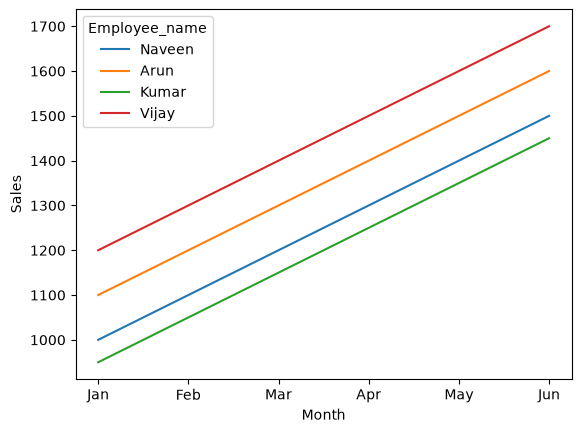

In [99]:
import seaborn as sns
sns.lineplot(
    data=df_long,
    x="Month",
    y="Sales",
    hue="Employee_name"
)

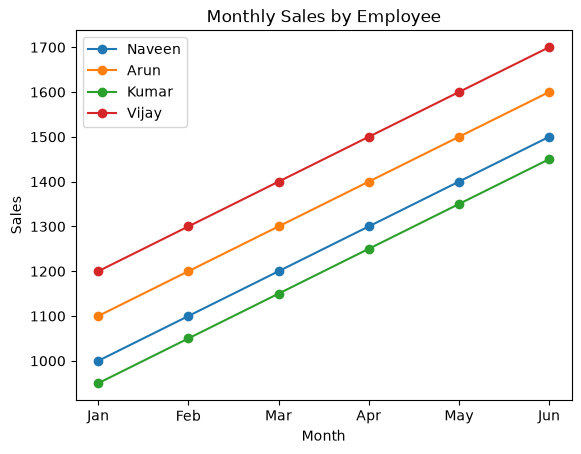

In [110]:
import matplotlib.pyplot as plt

for employee in df_long["Employee_name"].unique():
    data = df_long[df_long["Employee_name"] == employee]
    plt.plot(data["Month"], data["Sales"], marker="o", label=employee)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales by Employee")
plt.legend()
plt.show()

PIVOT

In [2]:
import pandas as pd
import numpy as np

In [7]:
df=pd.DataFrame({
    "Employee_name":["Naveen","Naveen","Arun","Arun"],
    "Month":["Jan","Feb","Jan","Feb"],
    "Sales":[50001,50000,48000,47000]
})

In [12]:
df.pivot(
    index="Employee_name",
    columns="Month",
    values="Sales"
)

Month,Feb,Jan
Employee_name,,
Arun,47000,48000
Naveen,50000,50001


In [30]:
df=pd.DataFrame({
    "Region":["south","north","north","south","south","north","south","north","south","north","south","north","south","north","south","north"],
    "product":["laptop","monitor","mobile","monitor","tab","laptop","mobile","tab","mobile","mobile","laptop","laptop","tab","tab","monitor","monitor"],
    "sales":[10,20,35,40,23,33,35,50,30,20,39,40,50,20,39,45]
})
df

,Region,product,sales
0,south,laptop,10
1,north,monitor,20
2,north,mobile,35
3,south,monitor,40
4,south,tab,23
5,north,laptop,33
6,south,mobile,35
7,north,tab,50
8,south,mobile,30
9,north,mobile,20


In [34]:
df.pivot_table(index="Region",columns="product",values="sales",aggfunc="sum")

product,laptop,mobile,monitor,tab
Region,,,,
north,73,55,65,70
south,49,65,79,73


In [36]:
import pandas as pd
import numpy as np
df=pd.read_csv("null.csv")
df.head(10)

,Employee_Id,Employee_Name,Month,Salary
0,1001.0,Arun,January,35000.0
1,1001.0,Arun,February,35000.0
2,1001.0,Arun,March,NaN
3,1001.0,Arun,April,35000.0
4,1001.0,NaN,May,35000.0
5,1001.0,Arun,June,35000.0
6,NaN,Arun,July,35000.0
7,1001.0,Arun,August,NaN
8,1001.0,Arun,September,35000.0
9,1001.0,Arun,October,35000.0


In [42]:
df.shape

(120, 4)

In [39]:
df.columns

Index(['Employee_Id', 'Employee_Name', 'Month', 'Salary'], dtype='str')

In [40]:
df.dtypes

Employee_Id      float64
Employee_Name        str
Month                str
Salary           float64
dtype: object

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Employee_Id    112 non-null    float64
 1   Employee_Name  106 non-null    str    
 2   Month          120 non-null    str    
 3   Salary         99 non-null     float64
dtypes: float64(2), str(2)
memory usage: 5.2 KB


In [44]:
df.isna().sum()

Employee_Id       8
Employee_Name    14
Month             0
Salary           21
dtype: int64

In [56]:
df["Employee_Name"].unique()

<ArrowStringArray>
[    'Arun',        nan,    'Priya',   ' Priya',    'Rahul',   ' Rahul',
    'Divya',  'Karthik', ' Karthik',   'Anitha',    'Vijay',   ' Vijay',
    'Sneha',   'Suresh',  ' Suresh',    'Meena']
Length: 16, dtype: str

In [51]:
df[df["Salary"].isna()]

,Employee_Id,Employee_Name,Month,Salary
2,1001.0,Arun,March,NaN
7,1001.0,Arun,August,NaN
13,1002.0,Priya,February,NaN
19,1002.0,Priya,August,NaN
27,1003.0,Rahul,April,NaN
34,1003.0,Rahul,November,NaN
40,1004.0,Divya,May,NaN
46,1004.0,Divya,November,NaN
48,1005.0,Karthik,January,NaN
54,1005.0,Karthik,July,NaN


In [54]:
df.groupby("Employee_Name").groups

{' Karthik': [56], ' Priya': [15], ' Rahul': [32], ' Suresh': [100], ' Vijay': [80], 'Anitha': [60, 62, 63, 64, 65, 66, 67, 68, 70, 71], 'Arun': [0, 1, 2, 3, 5, 6, 7, 8, 9, 11], 'Divya': [36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47], 'Karthik': [48, 49, 50, 51, 52, 54, 55, 57, 58, 59], 'Meena': [108, 109, 110, 112, 113, 114, 115, 116, 118, 119], 'Priya': [12, 13, 14, 16, 18, 19, 20, 21, 22, 23], 'Rahul': [24, 25, 27, 28, 29, 30, 31, 33, 34, 35], 'Sneha': [84, 85, 87, 88, 89, 90, 91, 92, 94, 95], 'Suresh': [96, 97, 98, 99, 101, 103, 104, 105, 106, 107], 'Vijay': [72, 73, 74, 75, 76, 77, 79, 81, 82, 83]}

In [55]:
df.groupby("Employee_Name").get_group("Arun")

,Employee_Id,Employee_Name,Month,Salary
0,1001.0,Arun,January,35000.0
1,1001.0,Arun,February,35000.0
2,1001.0,Arun,March,NaN
3,1001.0,Arun,April,35000.0
5,1001.0,Arun,June,35000.0
6,NaN,Arun,July,35000.0
7,1001.0,Arun,August,NaN
8,1001.0,Arun,September,35000.0
9,1001.0,Arun,October,35000.0
11,1001.0,Arun,December,35000.0


In [65]:
def find_nan_salary(df):
    for name, group in df.groupby("Employee_Name"):
        nan_rows = group[group["Salary"].isnull()]
        
        if not nan_rows.empty:
            print("\nEmployee:", name)
            print(nan_rows)


In [67]:
df[df["Salary"].isna() & df["Employee_Id"].isna()]

,Employee_Id,Employee_Name,Month,Salary


In [ ]:
df.dropna()

,Employee_Id,Employee_Name,Month,Salary
0,1001.0,Arun,January,35000.0
1,1001.0,Arun,February,35000.0
3,1001.0,Arun,April,35000.0
5,1001.0,Arun,June,35000.0
8,1001.0,Arun,September,35000.0


In [70]:
df.dropna(subset=["Salary"])

,Employee_Id,Employee_Name,Month,Salary
0,1001.0,Arun,January,35000.0
1,1001.0,Arun,February,35000.0
3,1001.0,Arun,April,35000.0
4,1001.0,NaN,May,35000.0
5,1001.0,Arun,June,35000.0
...,...,...,...,...
114,1010.0,Meena,July,50000.0
115,NaN,Meena,August,50000.0
116,1010.0,Meena,September,50000.0
117,1010.0,NaN,October,50000.0


In [81]:
avg_salary = df.groupby("Employee_Name")["Salary"].transform("mean")

df["Salary"] = df["Salary"].fillna(avg_salary)
df["Salary"].head(20)

0     35000.0
1     35000.0
2     35000.0
3     35000.0
4     35000.0
5     35000.0
6     35000.0
7     35000.0
8     35000.0
9     35000.0
10    35000.0
11    35000.0
12    40000.0
13    40000.0
14    40000.0
15    40000.0
16    40000.0
17    40000.0
18    40000.0
19    40000.0
Name: Salary, dtype: float64

In [90]:
df["Employee_Id"] = df["Employee_Id"].ffill().bfill()
df["Employee_Name"] = df["Employee_Name"].ffill().bfill()
df.head(20)

,Employee_Id,Employee_Name,Month,Salary
0,1001.0,Arun,January,35000.0
1,1001.0,Arun,February,35000.0
2,1001.0,Arun,March,35000.0
3,1001.0,Arun,April,35000.0
4,1001.0,Arun,May,35000.0
5,1001.0,Arun,June,35000.0
6,1001.0,Arun,July,35000.0
7,1001.0,Arun,August,35000.0
8,1001.0,Arun,September,35000.0
9,1001.0,Arun,October,35000.0


In [92]:
df.isna().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Employee_Id    120 non-null    float64
 1   Employee_Name  120 non-null    str    
 2   Month          120 non-null    str    
 3   Salary         120 non-null    float64
dtypes: float64(2), str(2)
memory usage: 5.2 KB


In [93]:
df.to_csv("null_cleaned.csv",index=False)